In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import numpy as np
from mpl_scatter_density import ScatterDensityArtist
from matplotlib.colors import Normalize, LogNorm, PowerNorm
from matplotlib.ticker import FormatStrFormatter
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
import functions as fn
import os
import sys

In [2]:
from importlib import reload
reload(fn)

<module 'functions' from '/global/u2/s/suhas31/thesisDraft2/functions.py'>

In [3]:
file_name = "/pscratch/sd/s/suhas31/Data/BGS_data.parquet"
DESI = pd.read_parquet(file_name)
DESI.columns

Index(['TargetID', 'RA', 'Dec', 'Z', 'M_u', 'M_g', 'M_r', 'M_i', 'M_z',
       'kcorr_u', 'kcorr_g', 'kcorr_r', 'kcorr_i', 'kcorr_z', 'ivar_M_u',
       'ivar_M_g', 'ivar_M_r', 'ivar_M_i', 'ivar_M_z', 'LogMstar', 'm_u',
       'm_g', 'm_r', 'm_i', 'm_z', 'ur', 'gr', 'N_N_1Mpc', 'LogMstar_N_1Mpc',
       'N_N_2Mpc', 'LogMstar_N_2Mpc', 'N_N_3Mpc', 'LogMstar_N_3Mpc'],
      dtype='object')

In [4]:
for i in DESI.columns:
    globals()[i] = np.array(DESI[i])

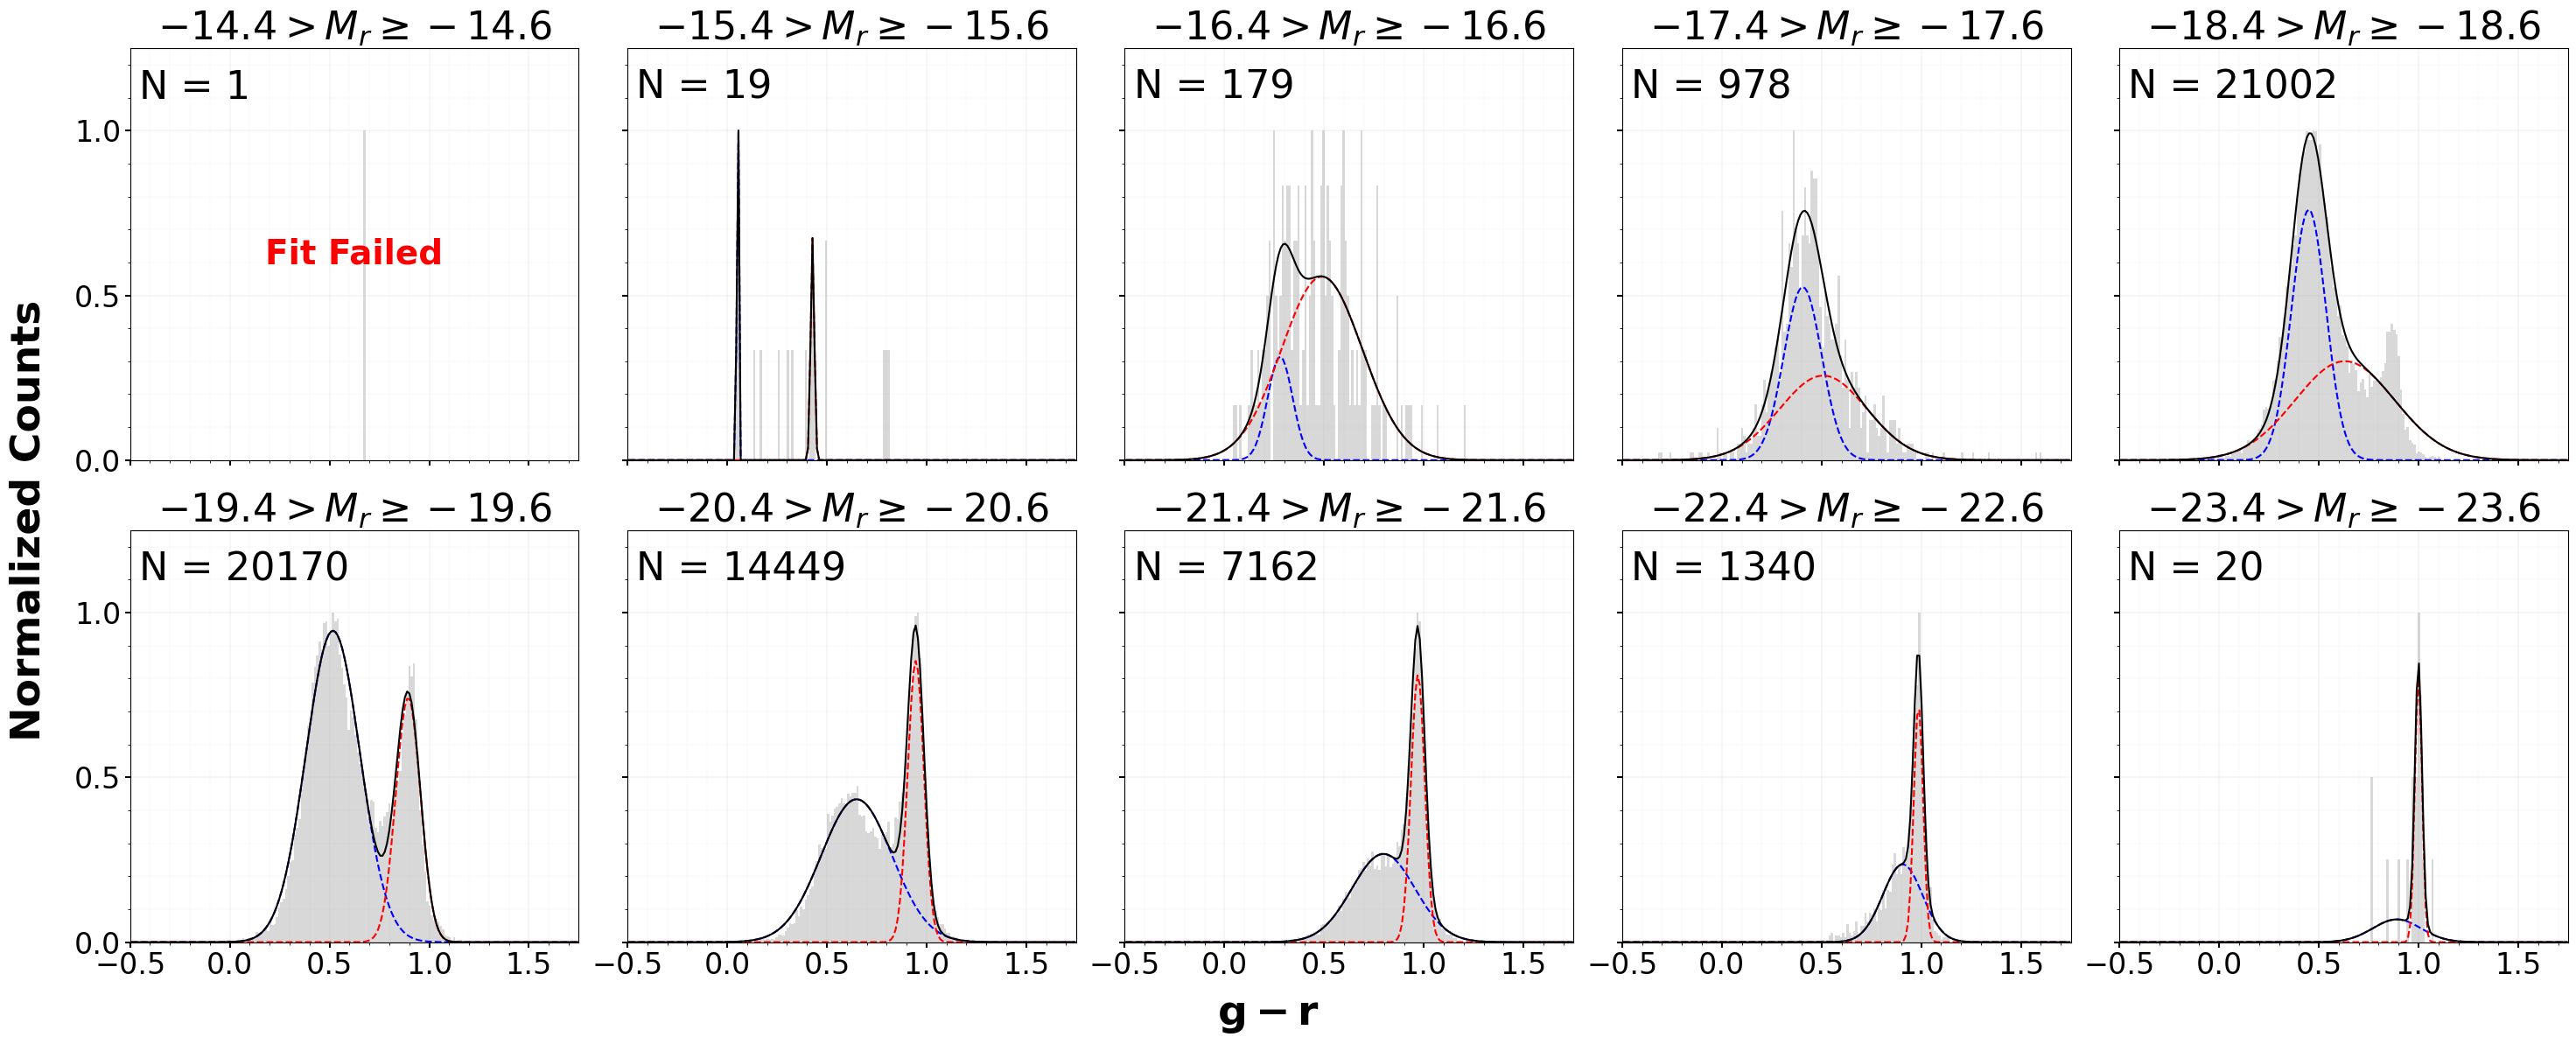

In [17]:
mask = (.075 < Z) & (Z <= .1)

Fig2_Z = Z[mask]
Fig2_Mr = M_r[mask]
Fig2_gr = gr[mask]

MrMin, MrMax, MrStep = -14., -24., -.2
MrEdges = np.arange(MrMin, MrMax + MrStep, MrStep)

grMin, grMax = -0.5, 1.75
grEdges = np.linspace(grMin, grMax, 201)

plt.rcParams.update({
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

fig, axs = plt.subplots(2, 5, figsize=(30, 12), sharex=True, sharey=True)
axs = axs.ravel()

for i in range(10):

    MrBin_mask = (MrEdges[i*5+2] > Fig2_Mr) & (Fig2_Mr >= MrEdges[i*5+3])
    Fig2_data = Fig2_gr[MrBin_mask]

    axs[i].set_title(
        f"${MrEdges[i*5+2]:.1f} > M_r \\geq {MrEdges[i*5+3]:.1f}$",
        fontsize=32
    )

    axs[i].minorticks_on()
    axs[i].grid(True, which="major", alpha=0.5, linewidth=.3)
    axs[i].grid(True, which="minor", alpha=0.5, linewidth=.1)

    if len(Fig2_data) == 0:
        axs[i].text(
            0.02, 0.95,
            f"N = {len(Fig2_data)}",
            transform=axs[i].transAxes,
            ha="left", va="top",
            fontsize=32
        )
        axs[i].text(
            0.5, 0.5, "Fit Failed",
            transform=axs[i].transAxes,
            ha="center", va="center",
            fontsize=28,
            color="red",
            weight="bold"
        )
        continue

    counts, _ = np.histogram(Fig2_data, bins=grEdges)
    peak = counts.max()

    if peak == 0:
        continue

    axs[i].hist(
        Fig2_data,
        bins=grEdges,
        weights=np.ones_like(Fig2_data) / peak,
        alpha=0.3,
        color="gray"
    )

    try:
        bin_centers, counts, dg_fit, gauss1, gauss2, popt = \
            fn.fit_double_gauss(Fig2_data, bins=grEdges)

        if np.sum(gauss1) > 0 and np.sum(gauss2) > 0:

            gauss1 = gauss1 / peak
            gauss2 = gauss2 / peak
            dg_fit = dg_fit / peak

            axs[i].plot(bin_centers, gauss1, "--", color="blue")
            axs[i].plot(bin_centers, gauss2, "--", color="red")
            axs[i].plot(bin_centers, dg_fit, "-", color="black")

            x_div, tau = fn.CR_div(bin_centers, gauss1, gauss2)
            # axs[i].axvline(x_div, color="green", linewidth=3)

            # tau_str = "NA" if not np.isfinite(tau) else f"{tau:.2f}"

            axs[i].text(
                0.02, 0.95,
                f"N = {len(Fig2_data)}",
                transform=axs[i].transAxes,
                ha="left", va="top",
                fontsize=32
            )

        else:
            axs[i].text(
                0.02, 0.95,
                f"N = {len(Fig2_data)}",
                transform=axs[i].transAxes,
                ha="left", va="top",
                fontsize=32
            )
            axs[i].text(
                0.5, 0.5,
                "Fit Failed",
                transform=axs[i].transAxes,
                ha="center", va="center",
                fontsize=28,
                color="red",
                weight="bold"
            )

    except Exception:
        axs[i].text(
            0.02, 0.95,
            f"N = {len(Fig2_data)}",
            transform=axs[i].transAxes,
            ha="left", va="top",
            fontsize=32
        )
        axs[i].text(
            0.5, 0.5,
            "Fit Failed",
            transform=axs[i].transAxes,
            ha="center", va="center",
            fontsize=28,
            color="red",
            weight="bold"
        )

    axs[i].set_xlim(-.25, 1.75)
    axs[i].set_ylim(0, 1.25)
    axs[i].set_xticks([-0.5, 0.0, 0.5, 1.0, 1.5])
    axs[i].set_yticks([0.0, 0.5, 1.0])

fig.supxlabel(r"$\mathbf{g-r}$", fontsize=34)
fig.supylabel("Normalized Counts", fontsize=34, weight='bold')

fig.tight_layout(rect=[0.02, 0., 1., 1.])

plt.savefig("/pscratch/sd/s/suhas31/ThesisFigures/dgFit_Row3.png", dpi=100)
plt.show()

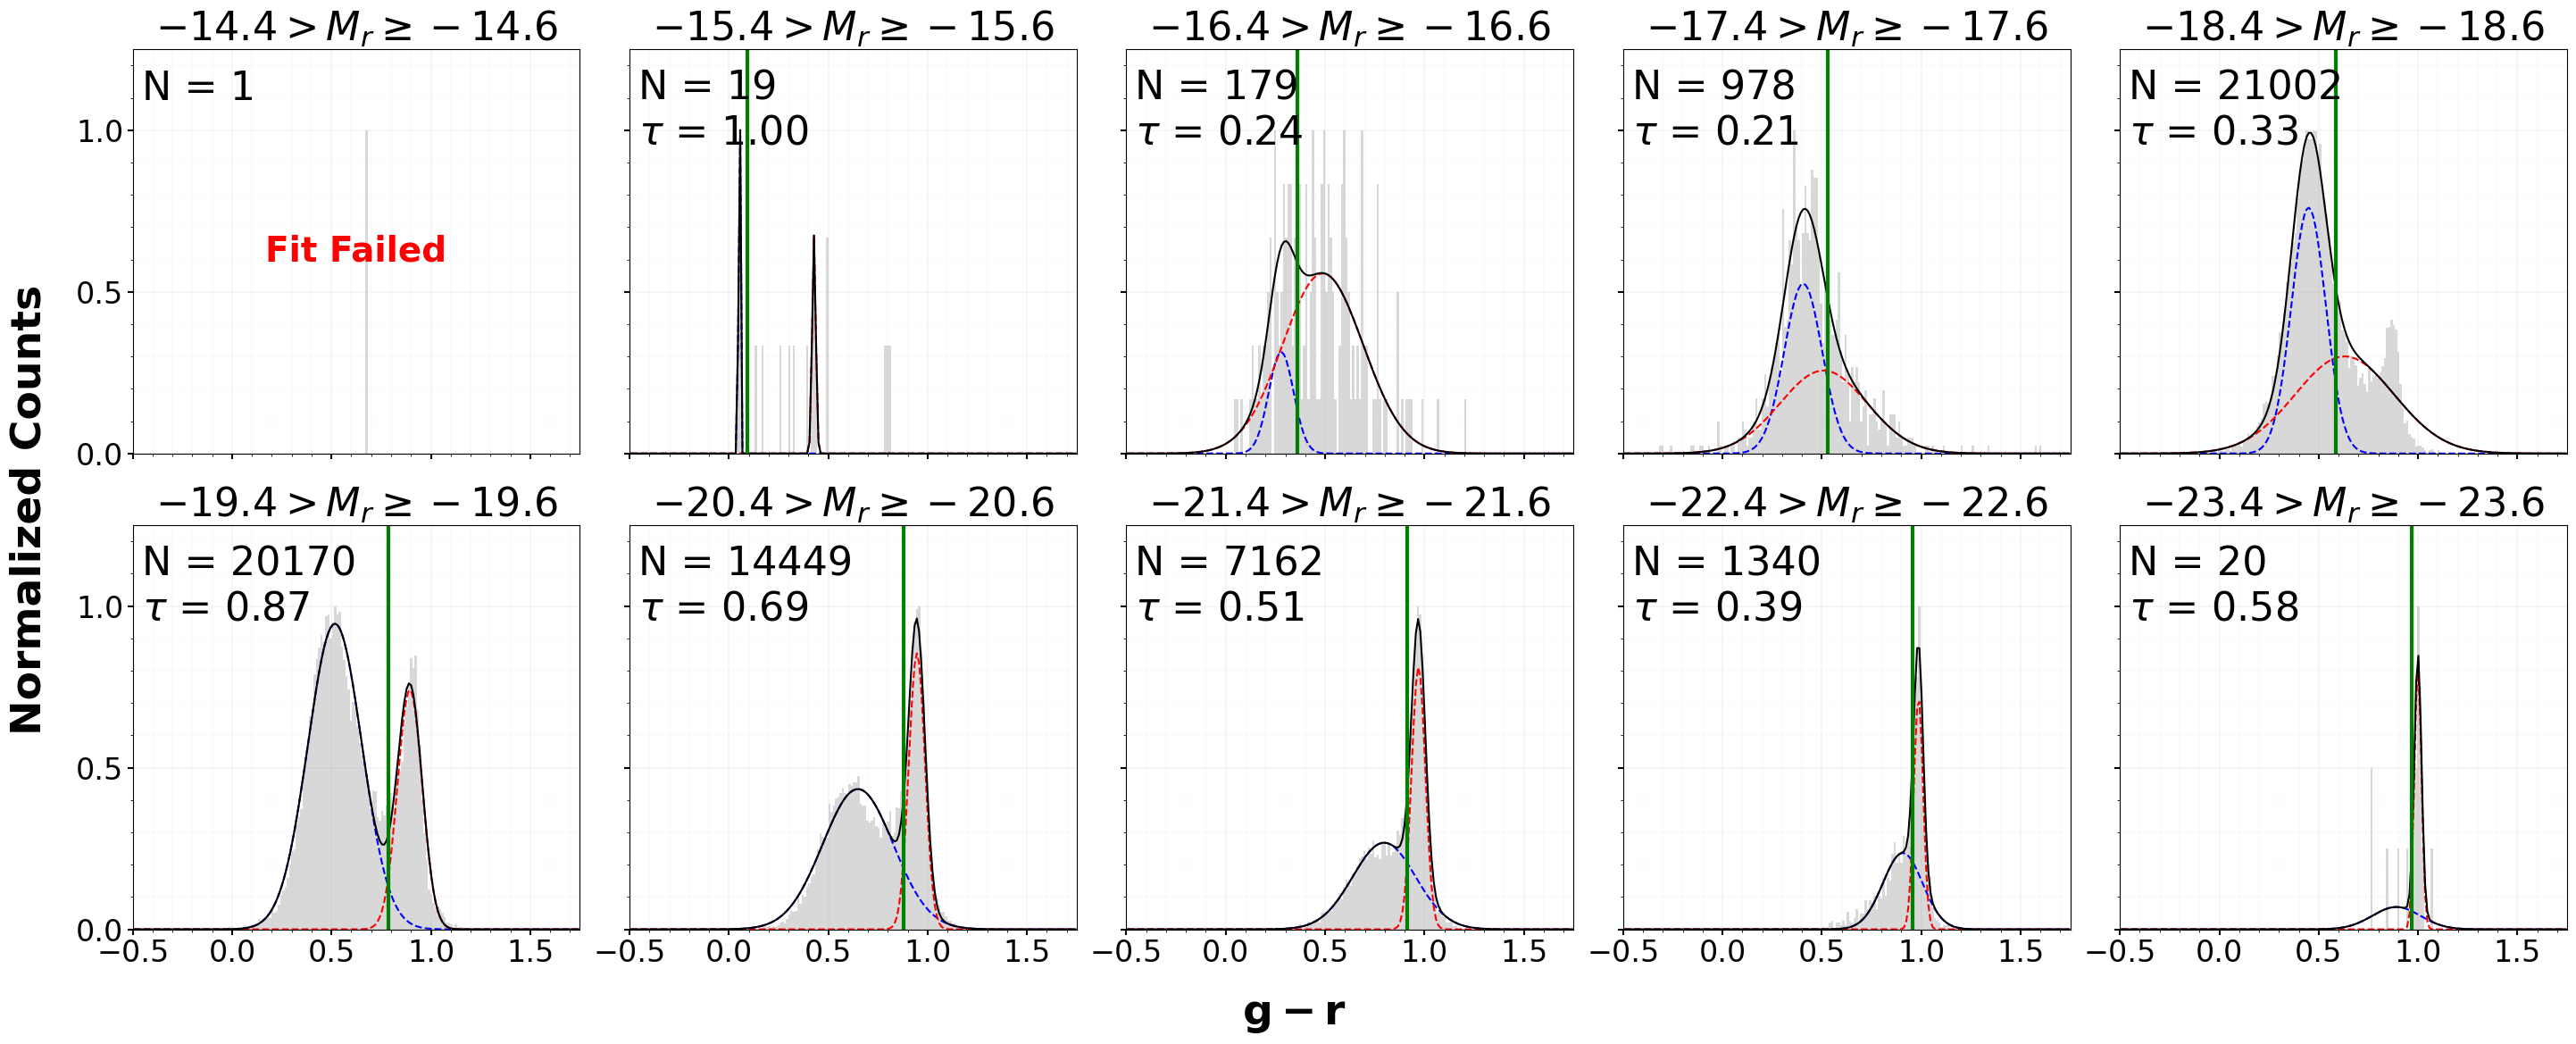

In [21]:
mask = (.075 < Z) & (Z <= .1)

Fig2_Z = Z[mask]
Fig2_Mr = M_r[mask]
Fig2_gr = gr[mask]

MrMin, MrMax, MrStep = -14., -24., -.2
MrEdges = np.arange(MrMin, MrMax + MrStep, MrStep)

grMin, grMax = -0.5, 1.75
grEdges = np.linspace(grMin, grMax, 201)

plt.rcParams.update({
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

fig, axs = plt.subplots(2, 5, figsize=(30, 12), sharex=True, sharey=True)
axs = axs.ravel()

for i in range(10):

    MrBin_mask = (MrEdges[i*5+2] > Fig2_Mr) & (Fig2_Mr >= MrEdges[i*5+3])
    Fig2_data = Fig2_gr[MrBin_mask]

    axs[i].set_title(
        f"${MrEdges[i*5+2]:.1f} > M_r \\geq {MrEdges[i*5+3]:.1f}$",
        fontsize=32
    )

    axs[i].minorticks_on()
    axs[i].grid(True, which="major", alpha=0.5, linewidth=.3)
    axs[i].grid(True, which="minor", alpha=0.5, linewidth=.1)

    if len(Fig2_data) == 0:
        axs[i].text(
            0.02, 0.95,
            f"N = {len(Fig2_data)}",
            transform=axs[i].transAxes,
            ha="left", va="top",
            fontsize=32
        )
        axs[i].text(
            0.5, 0.5, "Fit Failed",
            transform=axs[i].transAxes,
            ha="center", va="center",
            fontsize=28,
            color="red",
            weight="bold"
        )
        continue

    counts, _ = np.histogram(Fig2_data, bins=grEdges)
    peak = counts.max()

    if peak == 0:
        continue

    axs[i].hist(
        Fig2_data,
        bins=grEdges,
        weights=np.ones_like(Fig2_data) / peak,
        alpha=0.3,
        color="gray"
    )

    try:
        bin_centers, counts, dg_fit, gauss1, gauss2, popt = \
            fn.fit_double_gauss(Fig2_data, bins=grEdges)

        if np.sum(gauss1) > 0 and np.sum(gauss2) > 0:

            gauss1 = gauss1 / peak
            gauss2 = gauss2 / peak
            dg_fit = dg_fit / peak

            axs[i].plot(bin_centers, gauss1, "--", color="blue")
            axs[i].plot(bin_centers, gauss2, "--", color="red")
            axs[i].plot(bin_centers, dg_fit, "-", color="black")

            x_div, tau = fn.CR_div(bin_centers, gauss1, gauss2)
            axs[i].axvline(x_div, color="green", linewidth=3)

            tau_str = "NA" if not np.isfinite(tau) else f"{tau:.2f}"

            axs[i].text(
                0.02, 0.95,
                f"N = {len(Fig2_data)}\n$\\tau$ = {tau_str}",
                transform=axs[i].transAxes,
                ha="left", va="top",
                fontsize=32
            )

        else:
            axs[i].text(
                0.02, 0.95,
                f"N = {len(Fig2_data)}",
                transform=axs[i].transAxes,
                ha="left", va="top",
                fontsize=32
            )
            axs[i].text(
                0.5, 0.5,
                "Fit Failed",
                transform=axs[i].transAxes,
                ha="center", va="center",
                fontsize=28,
                color="red",
                weight="bold"
            )

    except Exception:
        axs[i].text(
            0.02, 0.95,
            f"N = {len(Fig2_data)}",
            transform=axs[i].transAxes,
            ha="left", va="top",
            fontsize=32
        )
        axs[i].text(
            0.5, 0.5,
            "Fit Failed",
            transform=axs[i].transAxes,
            ha="center", va="center",
            fontsize=28,
            color="red",
            weight="bold"
        )

    axs[i].set_xlim(grMin, grMax)
    axs[i].set_ylim(0, 1.25)
    axs[i].set_xticks([-0.5, 0.0, 0.5, 1.0, 1.5])
    axs[i].set_yticks([0.0, 0.5, 1.0])

fig.supxlabel(r"$\mathbf{g-r}$", fontsize=34)
fig.supylabel("Normalized Counts", fontsize=34, weight='bold')

fig.tight_layout(rect=[0.02, 0.01, 0.98, 0.98])

plt.savefig("/pscratch/sd/s/suhas31/ThesisFigures/GVDiv_Row3.png", dpi=100)
plt.show()

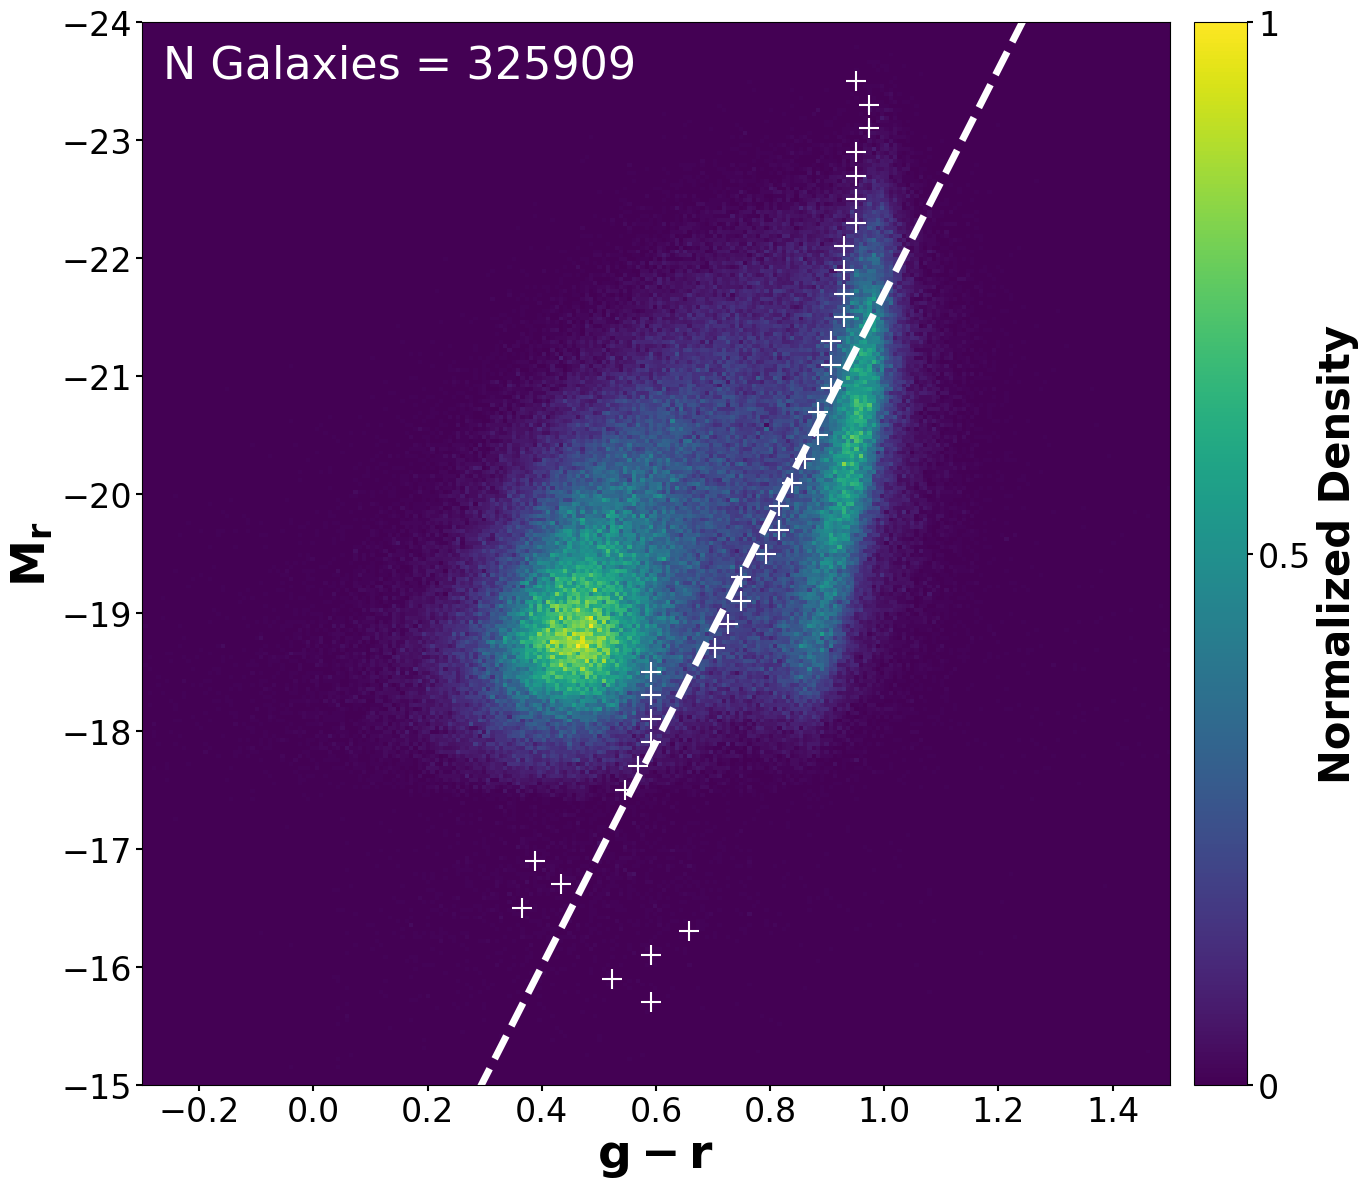

In [8]:
mask = (0.075 < Z) & (Z <= 0.1)

fig4Gr = gr[mask]
fig4Mr = M_r[mask]

numGal = len(fig4Gr)
w = np.ones_like(fig4Gr, dtype=float) / numGal  # keeping this since you had it

mrMin, mrMax, mrStep = -24., -14., 0.2
mrEdges = np.arange(mrMin, mrMax + mrStep, mrStep)
mrCenters = (mrEdges[:-1] + mrEdges[1:]) / 2

grMin, grMax = -.5, 1.75
grEdges = np.linspace(grMin, grMax, 101)

dividers = []
mrVals = []
weights = []

for mrCenter in mrCenters:
    maskMr = (fig4Mr >= mrCenter - mrStep/2) & (fig4Mr < mrCenter + mrStep/2)
    if np.count_nonzero(maskMr) < 20:
        continue

    grVals = fig4Gr[maskMr]
    try:
        binCenters, counts, dgFit, gauss1, gauss2, popt = fn.fit_double_gauss(grVals, bins=grEdges)
        xDiv, _ = fn.CR_div(binCenters, gauss1, gauss2)
        if xDiv is not None:
            dividers.append(xDiv)
            mrVals.append(mrCenter)
            weights.append(np.count_nonzero(maskMr))
    except Exception:
        continue

cmap = plt.cm.viridis.copy()
darkest = plt.cm.viridis(0.0)

plt.rcParams.update({
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor(darkest)

# -----------------------------
# density grid (your data -> 2D pixels)
# -----------------------------
# fixed grid resolution (same for every redshift slice)
# bump 300 -> 400 if you want sharper pixels, or 200 if you want faster
numBins = 300
grBins = np.linspace(grMin, grMax, numBins + 1)
mrBins = np.linspace(mrMin, mrMax, numBins + 1)

# histogram2d expects x then y; output is [xBin, yBin]
h2d, _, _ = np.histogram2d(fig4Gr, fig4Mr, bins=[grBins, mrBins])

# transpose so array is [y, x] for plotting
h2d = h2d.T

# normalize per slice to [0, 1]
hMax = h2d.max()
hNorm = (h2d / hMax) if hMax > 0 else h2d

# same PowerLaw scaling on every plot
norm = PowerNorm(gamma=0.5, vmin=0.0, vmax=1.0)

im = ax.imshow(
    hNorm,
    origin='lower',
    extent=[grMin, grMax, mrMin, mrMax],  # maps pixels -> CMD coordinates
    cmap=cmap,
    # norm=norm,
    aspect='auto',
    interpolation='nearest'
)

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02
)

# raw split-points
ax.scatter(dividers, mrVals, marker='+', c='white', s=200)

# weighted linear fit
if len(dividers) >= 2:
    coefs1 = np.polyfit(mrVals, dividers, deg=1, w=weights)
    p1 = np.poly1d(coefs1)
    xs = np.array([-10, -30])
    ax.plot(p1(xs), xs, '--', c='white', label='_nolegend_', linewidth=5)

ax.text(
    0.02, 0.98,
    f'N Galaxies = {numGal}',
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=32,
    color='white'
)

cbar.set_label('Normalized Density', fontsize=30, weight='bold')
# cbar.ax.yaxis.label.set_size(18)
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.ax.set_yticklabels(['0', '0.5', '1'])

ax.set_xlabel(r'$\mathbf{g - r}$', fontsize=34)
ax.set_ylabel(r'$\mathbf{M_r}$', fontsize=34)
ax.set_xlim([-.3, 1.5])
# ax.set_xticks([0.0, 0.5, 1.0])
ax.set_ylim([-15, -24])

plt.savefig("/pscratch/sd/s/suhas31/ThesisFigures/LinearDivider.png", dpi=100)

fig.tight_layout()
plt.show()
